# **Analisis variables - Adultos vs Kids**

# Bibliotecas

In [1]:
#Carga de datos
import pandas as pd
import numpy as np
import json
from Server_PD import download_dataframe_minio

from collections import Counter
import re

import seaborn as sns
import matplotlib.pyplot as plt
import isodate

# Carga de datos

In [2]:
# 1. Cargar claves
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]

# 2. Lista completa de todos los archivos visibles en tus capturas (sin .parquet)
nombres_archivos = [
    # Archivos del 24 de febrero
    "data_videos_2026-02-24_19-28-00",
    "df_videos_2026-02-24_20-25-50",
    # Archivos del 25 de febrero
    "df_videos_2026-02-25_09-54-10",
    "df_videos_2026-02-25_10-35-57",
    "df_videos_2026-02-25_11-30-05",
    "df_videos_2026-02-25_12-03-32",
    "df_videos_2026-02-25_12-10-47",
    "df_videos_2026-02-25_12-43-27",
    "df_videos_2026-02-25_12-51-47",
    "df_videos_2026-02-25_13-33-42",
    "df_videos_2026-02-25_14-04-11",
    "df_videos_2026-02-25_14-17-06",
    "df_videos_2026-02-25_15-09-41",
    "df_videos_2026-02-25_16-31-48",
    "df_videos_2026-02-25_17-33-15",
    # Archivos del 26 de febrero
    "df_videos_2026-02-26_11-18-58",
    "df_videos_2026-02-26_11-21-17",
    "df_videos_2026-02-26_11-44-50",
    "df_videos_2026-02-26_11-46-11",
    "df_videos_2026-02-26_12-11-49",
    "df_videos_2026-02-26_12-13-38",
    "df_videos_2026-02-26_15-48-40",
    "df_videos_2026-02-26_15-49-15",
    "df_videos_2026-02-26_16-15-25",
    "df_videos_2026-02-26_16-17-39",
    "df_videos_2026-02-26_17-12-35",
    "df_videos_2026-02-26_17-40-34"
]

# Añadimos el prefijo de la carpeta grupo1 a todos
archivos_a_descargar = [f"grupo1/{n}" for n in nombres_archivos]

lista_df = []

print("Iniciando descarga masiva desde MinIO...")

for nombre in archivos_a_descargar:
    try:
        temp_df = download_dataframe_minio(
            bucket="pd1", 
            object_name=nombre, 
            claves=claves, 
            file_format="parquet"
        )
        lista_df.append(temp_df)
        print(f"Descargado: {nombre}")
    except Exception as e:
        print(f"Error con {nombre}: {e}")

# 3. Concatenar y limpiar
if lista_df:
    df = pd.concat(lista_df, ignore_index=True)
    
    # Limpieza de duplicados por ID de video
    if 'video_id' in df.columns:
        antes = len(df)
        df = df.drop_duplicates(subset=['video_id'])
        despues = len(df)
        print(f"\nSe eliminaron {antes - despues} filas duplicadas.")
    
    print(f"\n¡Listo! Tienes un total de {len(df)} filas únicas para analizar.")
else:
    print("\nNo se pudo descargar ningún archivo. Verifica la conexión o los nombres.")

Iniciando descarga masiva desde MinIO...
Descargado: grupo1/data_videos_2026-02-24_19-28-00
Descargado: grupo1/df_videos_2026-02-24_20-25-50
Descargado: grupo1/df_videos_2026-02-25_09-54-10
Descargado: grupo1/df_videos_2026-02-25_10-35-57
Descargado: grupo1/df_videos_2026-02-25_11-30-05
Descargado: grupo1/df_videos_2026-02-25_12-03-32
Descargado: grupo1/df_videos_2026-02-25_12-10-47
Descargado: grupo1/df_videos_2026-02-25_12-43-27
Descargado: grupo1/df_videos_2026-02-25_12-51-47
Descargado: grupo1/df_videos_2026-02-25_13-33-42
Descargado: grupo1/df_videos_2026-02-25_14-04-11
Descargado: grupo1/df_videos_2026-02-25_14-17-06
Descargado: grupo1/df_videos_2026-02-25_15-09-41
Descargado: grupo1/df_videos_2026-02-25_16-31-48
Descargado: grupo1/df_videos_2026-02-25_17-33-15
Descargado: grupo1/df_videos_2026-02-26_11-18-58
Descargado: grupo1/df_videos_2026-02-26_11-21-17
Descargado: grupo1/df_videos_2026-02-26_11-44-50
Descargado: grupo1/df_videos_2026-02-26_11-46-11
Descargado: grupo1/df_vide

# Transformamos la columna "Duracion"

In [3]:

def iso_a_minutos(iso_duration):
    """"
    Funcion que convierte la duracion a minutos
    """
    try:
        duracion = isodate.parse_duration(iso_duration)
        return duracion.total_seconds() / 60
    except:
        return 0

df['Duracion'] = df['Duracion'].apply(iso_a_minutos)

# Dividimos los datos en "Adult" y "Kids"

In [6]:
# Kids
rangos_kids = ['0-4', '5-8', '9-12']
df_Kids = df[df["Rango_edad"].isin(rangos_kids)].copy()

# Adults
df_Adult = df[df["Rango_edad"] == "Adult"].copy()
df_Adult = df_Adult.head(len(df_Kids)).copy()


# Duración

In [7]:
def graficar_histograma_duracion(df, titulo, ax_obj, color):
    """"
    Funcion que genera un histograma comparativo de la duración de los vídeos
    """
    limite_sugerido = df['Duracion'].quantile(0.98)
    limite_final = int(np.ceil(limite_sugerido / 5) * 5)
    limite_final = max(min(limite_final, 90), 15)

    sns.histplot(df['Duracion'], bins=limite_final, kde=True, color=color, ax=ax_obj, edgecolor='white', alpha=0.7)
    
    ax_obj.set_title(titulo)
    ax_obj.set_xlabel('Minutos')
    ax_obj.set_ylabel('Cantidad de Vídeos')
    
    ax_obj.set_xlim(0, limite_final)

    ticks = np.arange(0, limite_final + 1, 5)
    ax_obj.set_xticks(ticks)
    ax_obj.set_xticklabels([f"{int(t)}" for t in ticks])

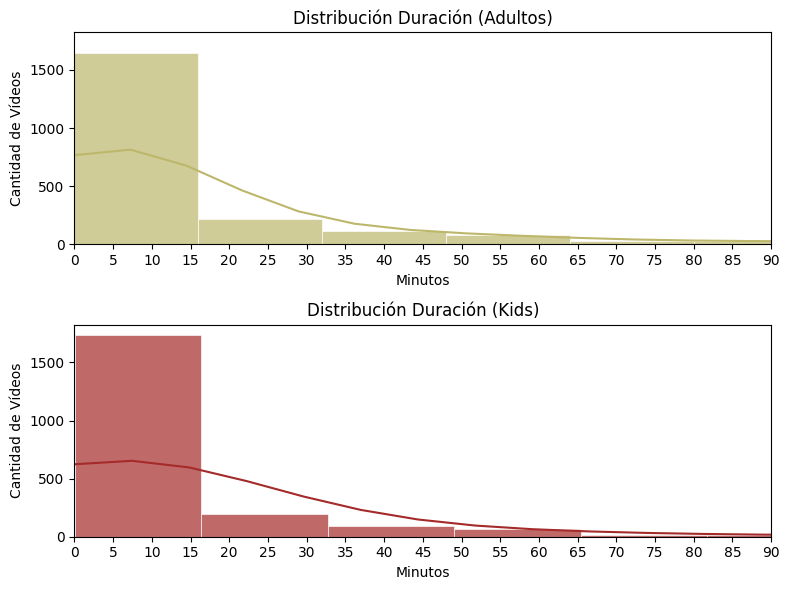

In [38]:

# Configuración
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharey=True)

graficar_histograma_duracion(df_Adult, 'Distribución Duración (Adultos)', ax[0], 'darkkhaki')
graficar_histograma_duracion(df_Kids, 'Distribución Duración (Kids)', ax[1], 'brown')

plt.tight_layout()
plt.show()

Kids: La distribución extremadamente concentrada en duraciones muy cortas (generalmente entre 0 y 15 minutos). Se puede observar qeu apenas hay videos de más de 15 minutos, lo que indica que el contenido infantil está diseñado para captar la atención de forma rápida y breve.

Adultos: Aunque también tiene un pico en duraciones cortas, hay más variedad. Desde vídeos cortos informativos (de entre 0-15 minutos) hasta contenidos más extensos que el público adulto es capaz de retener.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6160\4239985363.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')


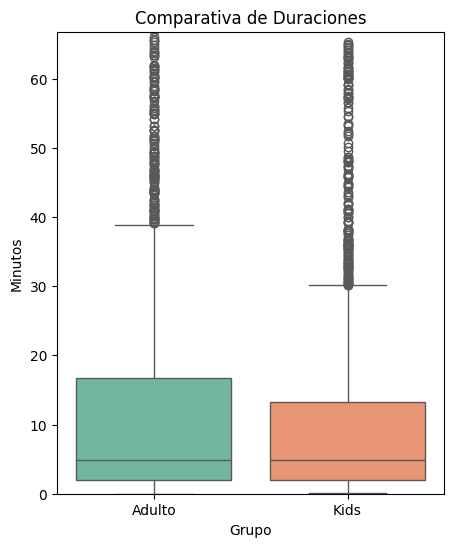

In [9]:
df_total = pd.concat([
    df_Adult.assign(Grupo='Adulto'),
    df_Kids.assign(Grupo='Kids')
])

plt.figure(figsize=(5, 6))
sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')     

# zoom para que se vea mejor
limite_superior = df_total['Duracion'].quantile(0.95) * 0.7 
plt.ylim(0, limite_superior) 

plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.show()

Como se puede observar la mediana es practicamente igual para adultos que para niños. Esto sugiere que hay un tiempo ideal para mantener la atención antes de que el usuario pase al siguiente vídeo, independientemente de su edad. Se puede estimar que este valor está entre 4 y 7 minutos.

La caja del grupo de adultos es más alta. Hay un mayor rango intercuartílico, lo que significa que no hay una duración estándar tan rígida como en los niños. Los adultos consumen una gama de tiempos mucho más amplia.

En ambos grupos vemos puntos por encima de los bigotes (outliers), pero en adultos estos valores extremos suelen llegar a duraciones mucho mayores, mientras que en niños, incluso los vídeos que se consideran más largos siguen teniendo una duracion razonable.

# Top 10 géneros

In [10]:

def graficar_top_generos(df, titulo_grafica, ax_obj, paleta):
    #  Limpiamos los datos
    generos = df['Generos'].astype(str).str.split(', ').explode()
    generos = generos[generos != 'nan']
    
    # top 10
    top_generos = generos.value_counts().head(10)
    
    # Grafica
    if not top_generos.empty:
        sns.barplot(x=top_generos.values, y=top_generos.index, palette=paleta, ax=ax_obj)
        ax_obj.set_title(titulo_grafica)
        ax_obj.set_xlabel('Frecuencia')
        ax_obj.set_ylabel('Género')
    else:
        ax_obj.set_title(f"{titulo_grafica} (Sin Datos)")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6160\3769986783.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette=paleta, ax=ax_obj)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6160\3769986783.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette=paleta, ax=ax_obj)


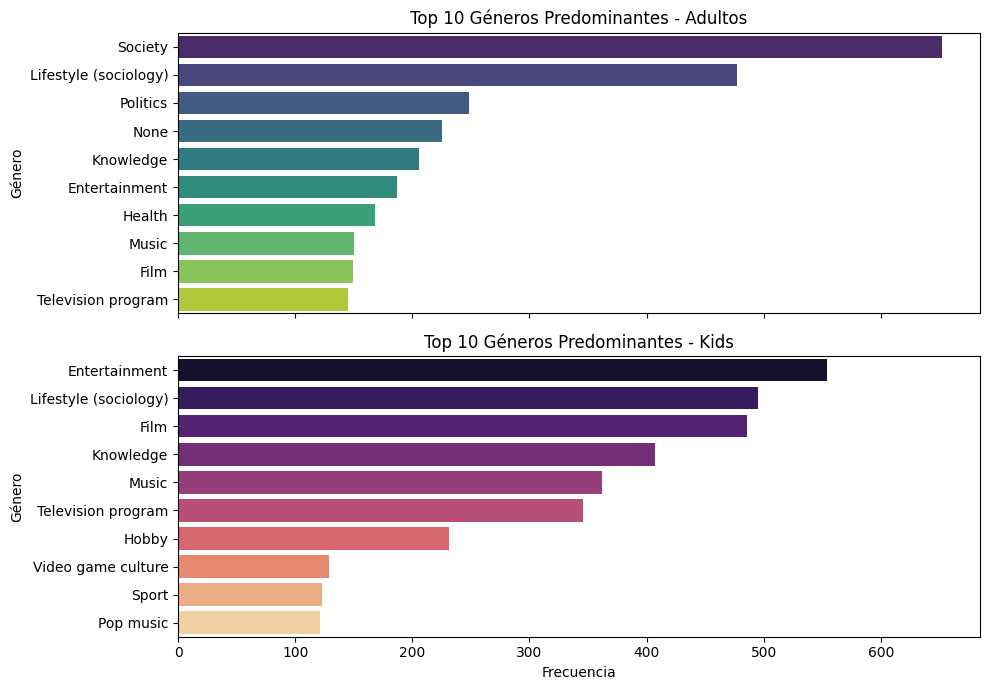

In [11]:
# Configuración
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Llamamos a la función para cada grupo
graficar_top_generos(df_Adult, 'Top 10 Géneros Predominantes - Adultos', ax[0], 'viridis')
graficar_top_generos(df_Kids, 'Top 10 Géneros Predominantes - Kids', ax[1], 'magma')

plt.tight_layout()
plt.show()

El perfil del público adulto destaca por su alta fragmentación y heterogeneidad temática. Conviven dos vertientes claras: por un lado, una fuerte inclinación hacia contenidos informativos y de actualidad ('Society', 'Politics', 'Knowledge') y, por otro, un consumo de ocio más tradicional ('Music', 'Film'). 

En cuanto al público infantil, se observa una polarización extrema. El contenido se agrupa casi exclusivamente en 'Entertainment' y 'Music', lo que define un patrón de consumo principalmente lúdico. A diferencia del equilibrio observado en los primeros 5 puestos del ranking adulto, en el segmento Kids los dos primeros generos acaparan el volumen total. 

Finalmente, la presencia significativa de vídeos no clasificados ('None') en ambos grupos representa un hallazgo crítico para la fase de modelado. Esto sugiere la existencia de contenidos híbridos que no encajan en las etiquetas predefinidas de la plataforma, lo que plantea el reto de refinar la limpieza de datos o considerar estas instancias como una categoría de "contenido inclasificable".

# Densidad de habla (wpm)

In [12]:
def calcular_wpm(row):

    """"
    Función que devuelve el numero de palabras por minuto de un vídeo. (Numero total de palabras /
    duración total del vídeo)
    """
    
    # Convertimos a string y  limpiamos nulos  NO SE SI ES NECESARIO
    sub_texto = str(row['Subtitulos'])
    if sub_texto == "None" or sub_texto == "nan" or row['Duracion'] == 0:
        return 0
    
    numero_palabras = len(sub_texto.split())
    return numero_palabras / row['Duracion']

In [13]:
#Agregamos una nueva columna a todos los df
df_Adult['Palabras_Por_Minuto'] = df_Adult.apply(calcular_wpm, axis=1)
df_Adult['Palabras_Por_Minuto'] = round(df_Adult['Palabras_Por_Minuto'], 2)

df_Kids['Palabras_Por_Minuto'] = df_Kids.apply(calcular_wpm, axis=1)
df_Kids['Palabras_Por_Minuto'] = round(df_Kids['Palabras_Por_Minuto'], 2)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6160\3964352962.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')


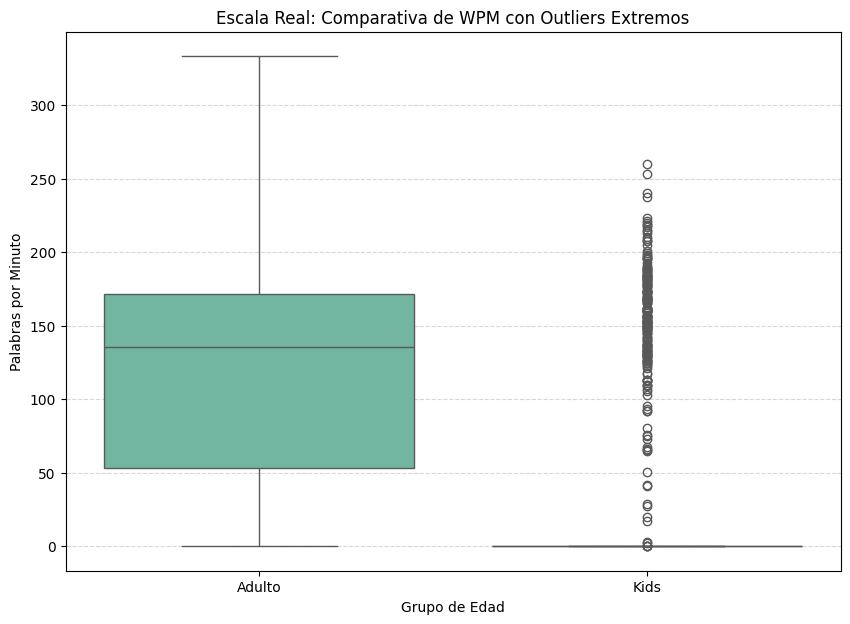

In [44]:
df_wpm_total = pd.concat([
    df_Adult.assign(Grupo='Adulto'),
    df_Kids.assign(Grupo='Kids')
])
# 2. Gráfica sin ninguna restricción de ejes
plt.figure(figsize=(10, 7))

# Graficamos permitiendo que Matplotlib decida el rango automáticamente
sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')

plt.title('Escala Real: Comparativa de WPM con Outliers Extremos')
plt.xlabel('Grupo de Edad')
plt.ylabel('Palabras por Minuto')

# Añadimos una cuadrícula más marcada para identificar los valores altos
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


Con el numero de palabras por minuto (wpm) somos capaces de medir la densidad de información verbal de los vídeos.

Los videos de adultos presentan una mediana de palabras por minuto significativamente más alta que el grupo infantil. Esto confirma que el contenido para adultos es predominantemente discursivo, apoyándose en la narrativa, la explicación y el diálogo.

La caja de 'kids' está situada en una zona de valores mucho más bajos. Esto valida la hipótesis de un consumo visual y musical, facilitando la comprensión para niños con menor capacidad lingüística. Tambien podemos suponer que se debe a que en los videos para niños se habla más lento debido a que tienen una capacidad de reteneción más limitada.

La caja del grupo Kids es más estrecha (menor rango intercuartílico), lo que indica que el ritmo de habla en los vídeos infantiles está muy estandarizado para no saturar al espectador.

El grupo Adulto muestra una caja mucho más amplia y bigotes extendidos. Esto refleja la coexistencia de géneros muy diversos. No existe un "estándar" de velocidad; conviven vídeos con una carga de guion muy densa (como las noticias) junto a otros donde la palabra es secundaria.


# Keywords 

In [31]:

# Lista extendida de stopwords en inglés
stopwords_en = {
    # Tus originales
    'the', 'and', 'a', 'to', 'of', 'in', 'is', 'it', 'you', 'that', 'he', 'was', 'for', 'on', 'are', 
    'with', 'as', 'i', 'his', 'they', 'be', 'at', 'one', 'have', 'this', 'from', 'or', 'had', 'by', 
    'hot', 'word', 'but', 'what', 'some', 'we', 'can', 'out', 'other', 'were', 'all', 'there', 
    'when', 'up', 'use', 'your', 'how', 'said', 'an', 'each', 'she', 'which', 'do', 'their', 
    'if', 'will', 'about', 'many', 'then', 'them', 'these', 'so', 'her', 'would', 'make', 
    'like', 'him', 'into', 'time', 'has', 'look', 'two', 'more', 'write', 'go', 'see', 
    'number', 'no', 'way', 'could', 'people', 'my', 'than', 'first', 'water', 'been', 
    'called', 'who', 'am', 'its', 'now', 'find', 'get', 'none', 'full', 'nbsp',
    'because', 'because', 'so', 'yet', 'unless', 'while', 'although', 'since', 'also',
    'just', 'very', 'really', 'even', 'still', 'maybe', 'actually', 'well', 'too', 'only',
    'never', 'always', 'sometimes', 'ever', 'again', 'back', 'here', 'there', 'where',
    'know', 'think', 'want', 'take', 'tell', 'come', 'give', 'mean', 'need', 'should',
    'right', 'let', 'may', 'must', 'keep', 'put', 'seem', 'look', 'much', 'many',
    'me', 'us', 'our', 'mine', 'ours', 'yourself', 'something', 'anything', 'everything',
    'another', 'every', 'own', 'same', 'such', 'very', 'next', 'right', 'okay', 'just', 'why', 'here'
    'not', 'yeah', 'kind'
}


def obtener_keywords_en(columna, top_n=20):
    todas_las_palabras = []
    # Filtramos nulos reales y strings que dicen 'None'/'nan'
    columna_limpia = columna.dropna().astype(str)
    columna_limpia = columna_limpia[~columna_limpia.str.lower().isin(['none', 'nan'])]

    for texto in columna_limpia:
        texto_limpio = texto.lower()
        palabras = re.findall(r'[a-z]+', texto_limpio)
        # Bajamos el filtro a > 2 porque en Kids hay palabras clave como 'Cat', 'Dog', 'Car'
        palabras_filtradas = [p for p in palabras if p not in stopwords_en and len(p) > 2]
        todas_las_palabras.extend(palabras_filtradas)
    
    return Counter(todas_las_palabras).most_common(top_n)



In [32]:

def graficar_palabras_comunes(df, columna, titulo_grafica, ax_obj, color):
    
    """"
    Funcion que genera un barplot de las top 10 palabras más comunes del título por cada grupo. 
    """

    keywords = obtener_keywords_en(df[columna], top_n=10)
    
    if not keywords:
        ax_obj.set_title(f"{titulo_grafica} (Sin datos)")
        return 

    # Desempaquetamos los resultados
    palabras_lista, conteos = zip(*keywords)
    
    # Dibujar grafica
    sns.barplot(x=list(conteos), y=list(palabras_lista), ax=ax_obj, color=color)
    ax_obj.set_title(titulo_grafica)
    ax_obj.set_xlabel('Frecuencia')
    ax_obj.set_ylabel('Palabra')

**TÍTULO**

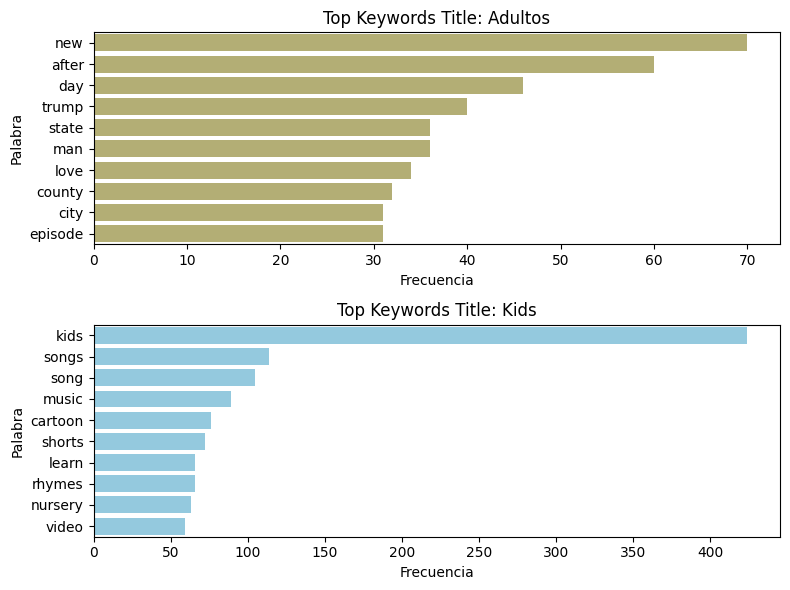

In [35]:
#Palabras más comunes en títulos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

graficar_palabras_comunes(df_Adult, 'Titulo', 'Top Keywords Title: Adultos', ax[0], 'darkkhaki')
graficar_palabras_comunes(df_Kids, 'Titulo', 'Top Keywords Title: Kids', ax[1], 'skyblue')

plt.tight_layout()
plt.show()

Se puede observar que los titulos de los videos adultos tienen un enfoque más informativo. Las palabras clave como 'Trailer', 'News', 'Trump', 'Official' y 'War' confirman un consumo basado en la actualidad política y el cine. Los títulos son descriptivos y parece que buscan informar sobre un contenido específico.

Por otro lado los titulos de los videos infantiles aparentan ser mas genéricos. Los términos predominantes son 'Kids', 'cartoon', 'Song', 'nursery'. Esto refuerza la idea de un consumo lúdico donde se busca el entretenimiento directo.

En el grupo Kids, el uso de la palabra 'kids' es masivo. Esto indica que el modelo de predicción de éxito para niños debería dar mucho peso a esta palabra, ya que define el producto de forma casi inequívoca.

En el grupo Adulto, vemos palabras como 'new' y 'day', lo que sugiere que el usuario adulto valora la actualidad del contenido.


**SUBTITULOS**

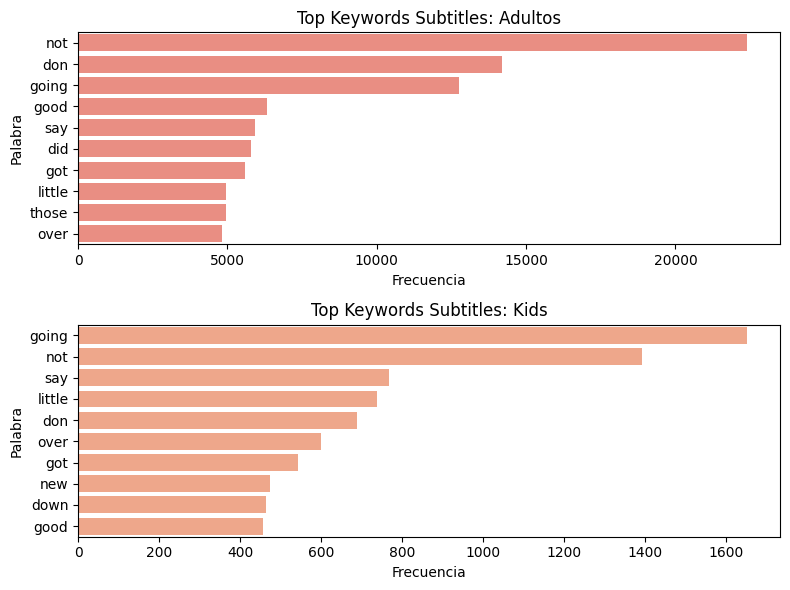

In [39]:
#Palabras mas comunes en subtítulos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

graficar_palabras_comunes(df_Adult, 'Subtitulos', 'Top Keywords Subtitles: Adultos', ax[0], 'salmon')
graficar_palabras_comunes(df_Kids, 'Subtitulos', 'Top Keywords Subtitles: Kids', ax[1], 'lightsalmon')

plt.tight_layout()
plt.show()